# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [40]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_raw_macro.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="stream2" # stream2 or timepoint

In [27]:
import sys
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
adata = sc.read(input_file)

In [42]:
adata.X.max()

np.float64(1915.0)

In [43]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [44]:
adata.X.max()

np.float64(7.988605460251196)

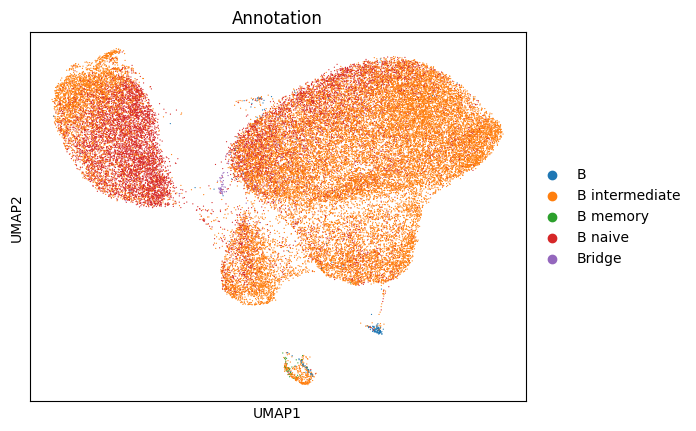

In [45]:
sc.pl.umap(adata,color=['Annotation'])

1) Evaluate the GO per macrostate (GO before HVG and binarization)

In [25]:
valid_states = ['I1', 'I2', 'T1', 'T2', 'T3']
adata_sub = adata[adata.obs['macrostates'].isin(valid_states)].copy()
#sc.pp.normalize_total(adata_sub)
#sc.pp.log1p(adata_sub)
sc.tl.rank_genes_groups(adata_sub,groupby='macrostates',method='wilcoxon',pts=True)


ZeroDivisionError: integer division or modulo by zero

2) Binarization with scBoolSeq

Binarization macrostates separately

In [46]:
if macrostates_computed=="timepoint":
    mapping = {0: "I1",1: "I2",2: "T1",3: "T2",4: "T3",5: "None"}
    adata.obs["macrostates"] = adata.obs["macrostates"].map(mapping)
    print(adata.obs["macrostates"].unique())

In [47]:
warnings.filterwarnings("ignore")
macrostates = ['I1', 'I2', 'T1', 'T2', "T3"]

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG adapted to the cell type size
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : Building the DataFrame for scBoolSeq
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Eliminate the 0 genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : Fit scBoolSeq on all the cell of the macrostate
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",# use quantile thresholds for zero-inflated genes
        margin_quantile=0.1, # 10th/90th percentile instead of 5th/95th
        dor_threshold=0.85, # classify as zero-inflated if >85% zeros
        alpha=0.0, # no IQR expansion (keep it simple)
    )
    scbool.fit(expr_df_full)
    print(f"  scBoolSeq fitted")

    # STEP 4 : Binarize per macrostate
    binarized = scbool.binarize(expr_df_full)

    # STEP 5 : Majority vote sur toutes les cellules
    def majority_vote(col):
        valid = col.dropna()
        if len(valid) == 0:
            return np.nan
        frac_ones = (valid == 1).mean()
        if frac_ones >= 0.5:
            return 1
        elif (valid == 0).mean() >= 0.5:
            return 0
        else:
            return np.nan

    aggregated = binarized.apply(majority_vote, axis=0)
    binarized_states[ct] = aggregated

    n_ones  = (aggregated == 1).sum()
    n_zeros = (aggregated == 0).sum()
    n_nan   = aggregated.isna().sum()
    print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")

    del adata_ct, expr_df_full, scbool
    gc.collect()

print("\nDone!")


Processing I1...


KeyError: 'macrostates'

In [10]:
pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')

,ISG15,TNFRSF4,SCNN1D,PEX10,PER3,ENO1,KIF1B,LRRC38,PDPN,KAZN,...,TCEAL3,NUP62CL,DCX,IL13RA1,ELF4,LDOC1,MAMLD1,MTMR1,PNMA5,ZFP92
I1,1.0,,,,1.0,1.0,1.0,,,,...,,,,,,,,,,
I2,1.0,,,,,1.0,,,,,...,,,,,,,,,,
T1,,,,,,,,,,,...,,,,,,,,,,
T3,1.0,1.0,,,1.0,,,,,,...,1.0,,,,,,,1.0,,
T2,,,,,,,,,,,...,,,,,,,,,,


In [29]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")
print(f"HVG macrostates: {hvg_mask.sum()} genes")

Total genes: 18723
HVG macrostates: 6399 genes


Scatter Plot

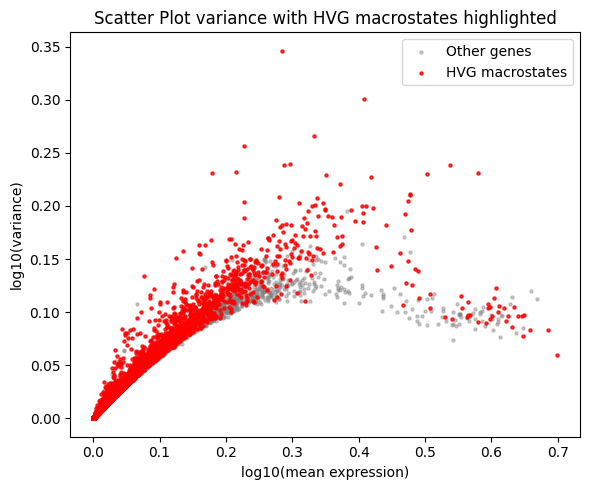

In [32]:
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Mean and variance per gene
means = np.mean(X, axis=0)      # (n_genes,)
vars_  = np.var(X, axis=0)      # (n_genes,)

log_means = np.log10(means + 1)
log_vars  = np.log10(vars_ + 1)

all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])

# Scatter plot mean–variance
plt.figure(figsize=(6, 5))
plt.scatter(
    log_means[~hvg_mask], log_vars[~hvg_mask],
    s=5, alpha=0.4, label="Other genes",
    c="gray")
plt.scatter(
    log_means[hvg_mask], log_vars[hvg_mask],
    s=5, alpha=0.8, label="HVG macrostates",
    c="red")
plt.xlabel("log10(mean expression)")
plt.ylabel("log10(variance)")
plt.title("Scatter Plot variance with HVG macrostates highlighted")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_directory}/scatterplot_macro.png", dpi=500, bbox_inches='tight')
plt.show()

Ratio variance inter and intra macrostates

In [15]:
print("Building global HVG matrix...")
all_hvg = list(all_hvg)
adata_hvg = adata[:, all_hvg].copy()

X = adata_hvg.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

valid_states = ['I1', 'I2', 'T1', 'T2', 'T3']
adata_hvg = adata_hvg[adata_hvg.obs['macrostates'].isin(valid_states)].copy()

print("Compute intra variance...")
intra_var = []
for c in np.unique(labels):
    idx = np.where(labels == c)[0]
    if len(idx) > 1:
        intra_var.append(np.mean(np.var(X[idx, :], axis=0)))

intra_var_mean = np.mean(intra_var)
print("Compute inter variance...")
means_per_cluster = np.array([
    X[np.where(labels == c)[0], :].mean(axis=0)
    for c in np.unique(labels)
])

inter_var = np.mean(np.var(means_per_cluster, axis=0))
ratio = inter_var / intra_var_mean if intra_var_mean > 0 else np.nan

print(f"Inter/Intra macrostate ratio: {ratio:.4f}")

Building global HVG matrix...
Compute intra variance...
Compute inter variance...
Inter/Intra macrostate ratio: 0.1149


ARI computated

In [34]:
adata.obsp.keys()

KeysView(PairwiseArrays with keys: connectivities, distances)

In [ ]:
n_pcs = 20
n_neighbors = 15
resolution = 1.0

# Clustering based on all the genes
adata_tg = adata.copy()
sc.tl.pca(adata_tg, n_comps=n_pcs, use_highly_variable=False)
sc.pp.neighbors(adata_tg, n_pcs=n_pcs, n_neighbors=n_neighbors)
sc.tl.louvain(adata_tg, resolution=resolution, key_added="louvain_TG")
# or sc.tl.leiden(adata_tg, resolution=resolution, key_added="leiden_TG")
print("Clustering with all the genes OK")

# Clustering based on the HVG per macrostates
all_genes = adata.var_names
hvg_mask_macro = np.array([gene in all_hvg for gene in all_genes])
adata_hvg_macro = adata[:, hvg_mask_macro].copy()
sc.tl.pca(adata_hvg_macro, n_comps=n_pcs, use_highly_variable=False)
sc.pp.neighbors(adata_hvg_macro, n_pcs=n_pcs, n_neighbors=n_neighbors)
sc.tl.louvain(adata_hvg_macro, resolution=resolution, key_added="louvain_HVG_macro")
print("Clustering with the HVG macrostates OK")

# Clustering based on the HVG on the complete population (all cells) 
adata_hvg_global = adata.copy()
# Calculer HVG sur tout le dataset (Seurat v3 / cell_ranger style)
sc.pp.highly_variable_genes(
    adata_hvg_global,
    n_top_genes=2000,
    flavor="cell_ranger",  # ou "seurat_v3"
)
sc.tl.pca(adata_hvg_global, n_comps=n_pcs, use_highly_variable=True)
sc.pp.neighbors(adata_hvg_global, n_pcs=n_pcs, n_neighbors=n_neighbors)
sc.tl.louvain(adata_hvg_global, resolution=resolution, key_added="louvain_HVG_global")
print("Clustering avec HVG globaux OK")